## Préparation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du livrable
df = pd.read_csv("../data/donnees.csv")
#df = pd.read_csv("../data/test7.csv")

# Nettoyage : conversion numérique
df['CVSS'] = pd.to_numeric(df['CVSS'], errors='coerce')
df['EPSS'] = pd.to_numeric(df['EPSS'], errors='coerce')

## Les graphiques

### Nuage de points (Scatter Plot) : CVSS vs EPSS

Si une CVE est en haut à droite (CVSS 9.8 + EPSS 0.95), c'est une urgence absolue

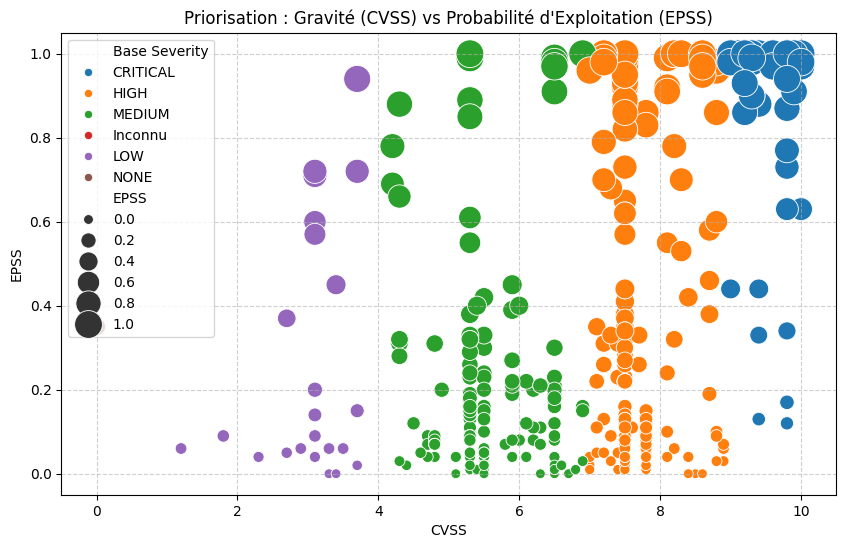

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CVSS', y='EPSS', hue='Base Severity', size='EPSS', sizes=(50, 400))
plt.title("Priorisation : Gravité (CVSS) vs Probabilité d'Exploitation (EPSS)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Distribution des scores CVSS (Histogramme)

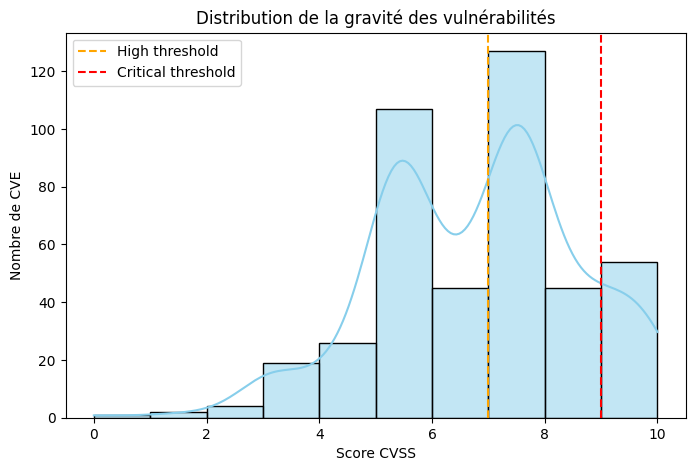

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(df['CVSS'], bins=10, kde=True, color='skyblue')
plt.axvline(x=7.0, color='orange', linestyle='--', label='High threshold')
plt.axvline(x=9.0, color='red', linestyle='--', label='Critical threshold')
plt.title("Distribution de la gravité des vulnérabilités")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.legend()
plt.show()

### Top 5 des faiblesses les plus fréquentes (CWE)

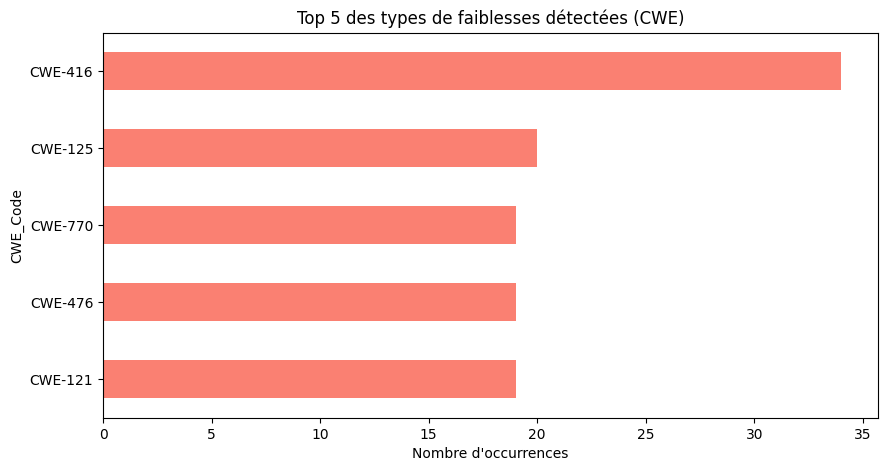

In [4]:
# On extrait juste le code CWE (ex: CWE-123) pour plus de clarté
df['CWE_Code'] = df['CWE'].str.extract(r'(CWE-\d+)')

plt.figure(figsize=(10, 5))
df['CWE_Code'].value_counts().head(5).plot(kind='barh', color='salmon')
plt.title("Top 5 des types de faiblesses détectées (CWE)")
plt.xlabel("Nombre d'occurrences")
plt.gca().invert_yaxis()
plt.show()

### Analyse par Autorité (Assigner)

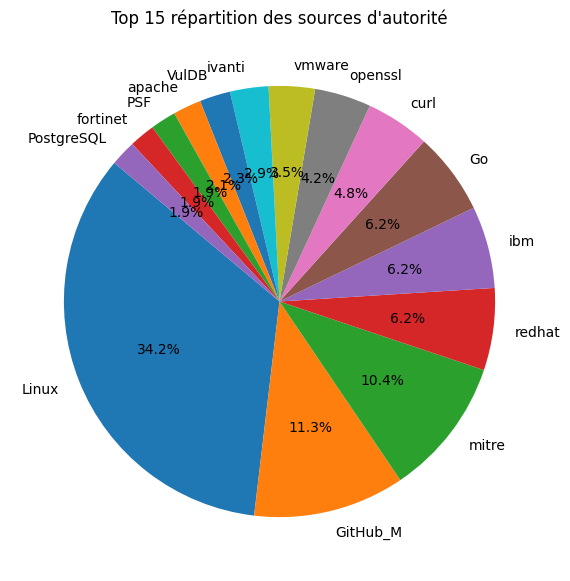

In [5]:
# On filtre pour ne garder que les lignes où l'organisation n'est pas "Inconnu"
df = df[df["Organisation d'autorité"] != "Inconnu"]
plt.figure(figsize=(7, 7))
df["Organisation d'autorité"].value_counts().head(15).plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Top 15 répartition des sources d'autorité")
plt.ylabel('')
plt.show()

### Top 10 des Vendeurs les plus affectés

Pour voir quel éditeur demande le plus de travail de mise à jour cette semaine.

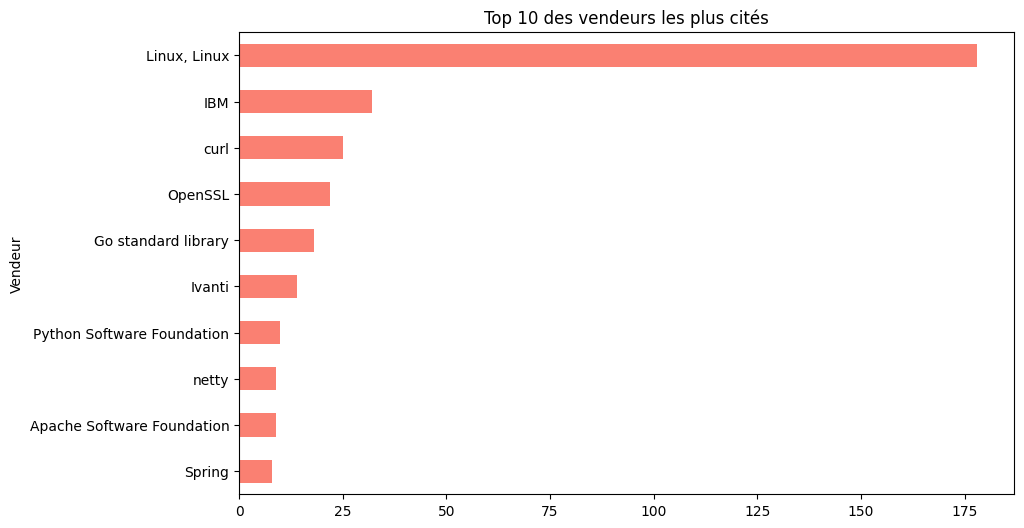

In [6]:
plt.figure(figsize=(10, 6))
df['Vendeur'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.gca().invert_yaxis() # Pour avoir le plus gros en haut
plt.title('Top 10 des vendeurs les plus cités')
plt.show()

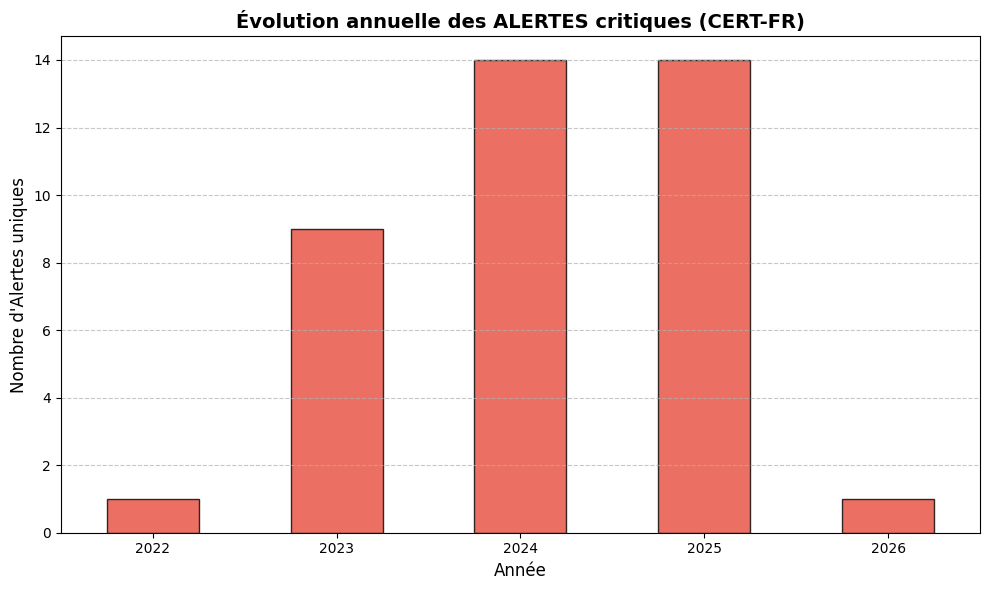

--- Récapitulatif des Alertes par année ---
 Année  Nombre d'Alertes
  2022                 1
  2023                 9
  2024                14
  2025                14
  2026                 1


In [7]:
# 1. Filtrer uniquement les lignes dont le titre commence par "Alerte"
# On utilise .str.startswith() pour isoler les alertes critiques de l'ANSSI
df_alertes = df[df['Bulletin_Titre'].str.startswith("Alerte", na=False)].copy()

# 2. Tri par nom et suppression des doublons de bulletins
# Un même bulletin "Alerte" peut lister plusieurs CVE, on ne garde que l'entité Bulletin unique
df_temporel = df_alertes.sort_values(by='Bulletin_Titre').drop_duplicates(subset=['Bulletin_Titre']).copy()

# 3. Conversion de la date
df_temporel['Bulletin_Date'] = pd.to_datetime(df_temporel['Bulletin_Date'])

# 4. Agrégation par ANNÉE
evol_annuelle = df_temporel.groupby(df_temporel['Bulletin_Date'].dt.year).size().sort_index()

# 5. Création du graphique
plt.figure(figsize=(10, 6))
evol_annuelle.plot(kind='bar', color='#e74c3c', edgecolor='black', alpha=0.8)

# Personnalisation
plt.title("Évolution annuelle des ALERTES critiques (CERT-FR)", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'Alertes uniques", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Affichage du récapitulatif
tableau_annuel = evol_annuelle.reset_index()
tableau_annuel.columns = ['Année', 'Nombre d\'Alertes']
print("--- Récapitulatif des Alertes par année ---")
print(tableau_annuel.to_string(index=False))

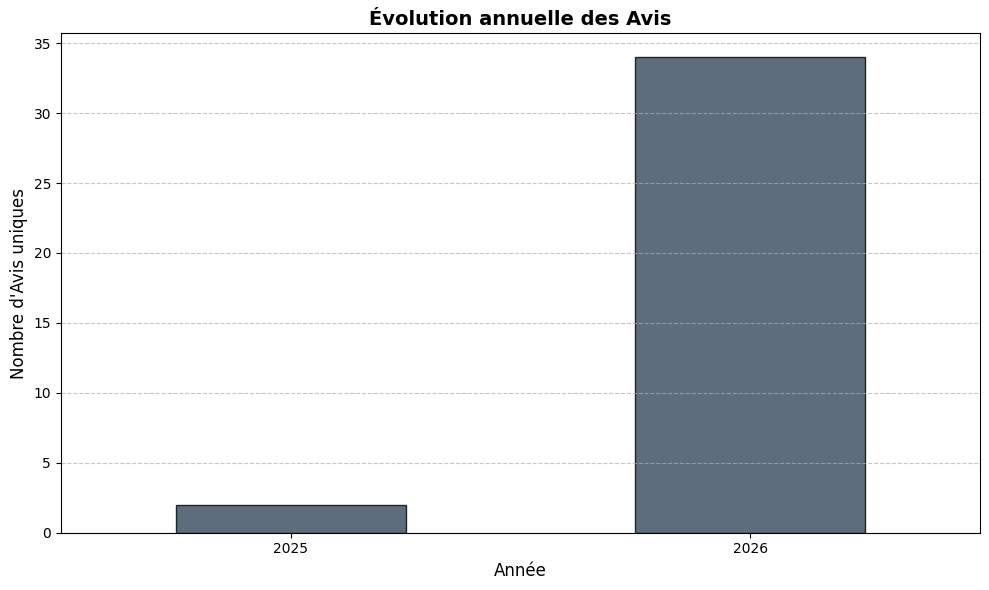

--- Récapitulatif des Avis par année ---
 Année  Nombre d'Avis
  2025              2
  2026             34


In [8]:
df_alertes = df[df['Bulletin_Titre'].str.startswith("Avis", na=False)].copy()

df_temporel = df_alertes.sort_values(by='Bulletin_Titre').drop_duplicates(subset=['Bulletin_Titre']).copy()

df_temporel['Bulletin_Date'] = pd.to_datetime(df_temporel['Bulletin_Date'])

evol_annuelle = df_temporel.groupby(df_temporel['Bulletin_Date'].dt.year).size().sort_index()

plt.figure(figsize=(10, 6))
evol_annuelle.plot(kind='bar', color='#34495e', edgecolor='black', alpha=0.8)

plt.title("Évolution annuelle des Avis", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'Avis uniques", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

tableau_annuel = evol_annuelle.reset_index()
tableau_annuel.columns = ['Année', 'Nombre d\'Avis']
print("--- Récapitulatif des Avis par année ---")
print(tableau_annuel.to_string(index=False))

In [9]:
import os

os.makedirs('../exports', exist_ok=True)
os.system('jupyter nbconvert analyse_data.ipynb --to html --no-input --output-dir="../exports"')

[NbConvertApp] Converting notebook analyse_data.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 615679 bytes to ../exports/analyse_data.html


0